# Imports and GPU setup

In [ ]:
# Run this in a fresh runtime, before importing tensorflow / keras / keras_hub
!pip uninstall -y tensorflow tensorflow-text keras keras-hub tf-keras
!pip install -U tensorflow tensorflow-text keras keras-hub
!pip install -q umap-learn

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorflow-text 2.20.0
Uninstalling tensorflow-text-2.20.0:
  Successfully uninstalled tensorflow-text-2.20.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: keras-hub 0.26.0
Uninstalling keras-hub-0.26.0:
  Successfully uninstalled keras-hub-0.26.0
  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached tensorflow_text-2.20.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached keras_hub-0.26.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl

In [ ]:
# Imports needed to run this notebook
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
from collections import Counter
from pathlib import Path
from PIL import Image

from google.colab import drive

import tensorflow as tf
import keras
import keras_hub
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
import kagglehub
from transformers import AutoTokenizer

In [ ]:
USE_MIXED_PRECISION = True

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print("Strategy:", type(strategy).__name__)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy


In [ ]:
# Model & training
IMG_SIZE = 224
MAX_LEN = 32
EMBED_DIM = 256

BATCH_SIZE = 4
EPOCHS = 10
LR = 1e-4

# Performance
AUTOTUNE = tf.data.AUTOTUNE

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Downloading and preparing the dataset

Lets load the input dataset chosen, a **lung and colon cancer** *histopathological image* dataset: https://arxiv.org/pdf/1912.12142v1

This dataset contains 25,000 histopathological images, patches of Whole Slide Images (WSI) for lung and colon tissues. All images are 768 x 768 pixels in size and are in jpeg file format.

Images are categorized in 5 classes:
- Lung bening tisues
- Lung adenocarcinoma
- Lung squamous cell carcinoma
- Colon bening tissue
- Colon adenocarcinoma



## Download the dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-and-colon-cancer-histopathological-images


In [ ]:
base_dir = "/lung_colon_image_set"
lung_dir = "/lung_image_sets"
colon_dir = "/colon_image_sets"
directories = [
    path + base_dir + lung_dir + "/lung_n",
    path + base_dir + lung_dir  + "/lung_aca",
    path + base_dir + lung_dir  + "/lung_scc",
    path + base_dir + colon_dir  + "/colon_n",
    path + base_dir + colon_dir  + "/colon_aca",
]

**We will assume that all images on the dataset have the same shape, so lets inspect first image to determine shape**

In [ ]:
sample_img = os.listdir(directories[0])[0]
sample_path = os.path.join(directories[0], sample_img)

with Image.open(sample_path) as img:
    sample = np.array(img)

H, W, C = sample.shape
H,W,C

(768, 768, 3)

Pre-allocate the arrays:

In [ ]:
images_per_class = [len(os.listdir(d)) for d in directories]
total_images = sum(images_per_class)

print("Images per class:", images_per_class)
print("Total images:", total_images)

Images per class: [5000, 5000, 5000, 5000, 5000]
Total images: 25000


In [ ]:
records = []
labels = []

# Since we know we have 5000 images of each class we can
# pre-allocate the y array
class_descriptions = [
    "A histopathology image of lung benign tissue",
    "A histopathology image of lung adenocarcinoma",
    "A histopathology image of lung squamous cell carcinoma",
    "A histopathology image of colon benign tissue",
    "A histopathology image of colon adenocarcinoma"
]

for i, n in enumerate(images_per_class):
    for j in range(n):
        labels.append(class_descriptions[i])

Load the images

In [ ]:
idx = 0
for dir in directories:
    for fname in os.listdir(dir):
        records.append(os.path.join(dir, fname))

In [ ]:
i = random.randint(0, 24999)
print(records[i])
print(labels[i])

/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_n/lungn3992.jpeg
A histopathology image of lung benign tissue


## Visualize the dataset

In [ ]:
def show_sample(records, labels, index):
    if index < 0 or index >= len(records):
        raise IndexError(f"Index {index} out of range (0 - {len(records)-1})")

    img_path, label = records[index], labels[index]
    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"Description: {label}", fontsize=12)
    plt.axis("off")
    plt.show()

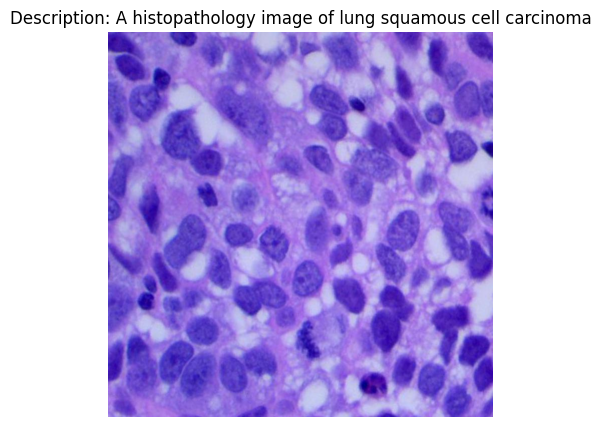

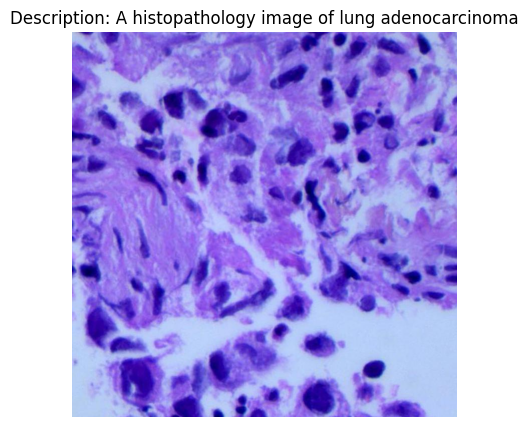

In [ ]:
i1, i2 = random.randint(0, 24999), random.randint(0, 24999)
show_sample(records, labels, i1)
show_sample(records, labels, i2)

# Model

## Define the model

In [ ]:
image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
text_backbone = keras_hub.models.Backbone.from_preset("bert_base_en_uncased")
text_preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=MAX_LEN,
)

image_backbone.trainable = False
text_backbone.trainable = False

image_backbone.summary()
text_backbone.summary()

Model: "res_net_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_co… │ (None, None,      │      4,096 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_bn  │ (None, None,      │        256 │ stack0_block0_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_re… │ (None, None,      │          0 │ stack0_block0_1_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_co… │ (None, None,      │     36,864 │ stack0_block0_1_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_bn  │ (None, None,      │        256 │ stack0_block0_2_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_re… │ (None, None,      │          0 │ stack0_block0_2_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_0_co… │ (None, None,      │     16,384 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_3_co… │ (None, None,      │     16,384 │ stack0_block0_2_… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_0_bn  │ (None, None,      │      1,024 │ stack0_block0_0_… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_3_bn  │ (None, None,      │      1,024 │ stack0_block0_3_

 Total params: 23,561,152 (89.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,561,152 (89.88 MB)

Model: "bert_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, None, 768) │ 23,440,896 │ token_ids[0][0]   │
│ (ReversibleEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, None, 768) │    393,216 │ token_embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_embedding   │ (None, None, 768) │      1,536 │ segment_ids[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_add      │ (None, None, 768) │          0 │ token_embedding[… │
│ (Add)               │                   │            │ position_embeddi… │
│                     │                   │            │ segment_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_layer_n… │ (None, None, 768) │      1,536 │ embeddings_add[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_dropout  │ (None, None, 768) │          0 │ embeddings_layer… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_0 │ (None, None, 768) │  7,087,872 │ embeddings_dropo… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_1 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_2 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_3 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_4 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_5 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_6 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 109,482,240 (417.64 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 109,482,240 (417.64 MB)

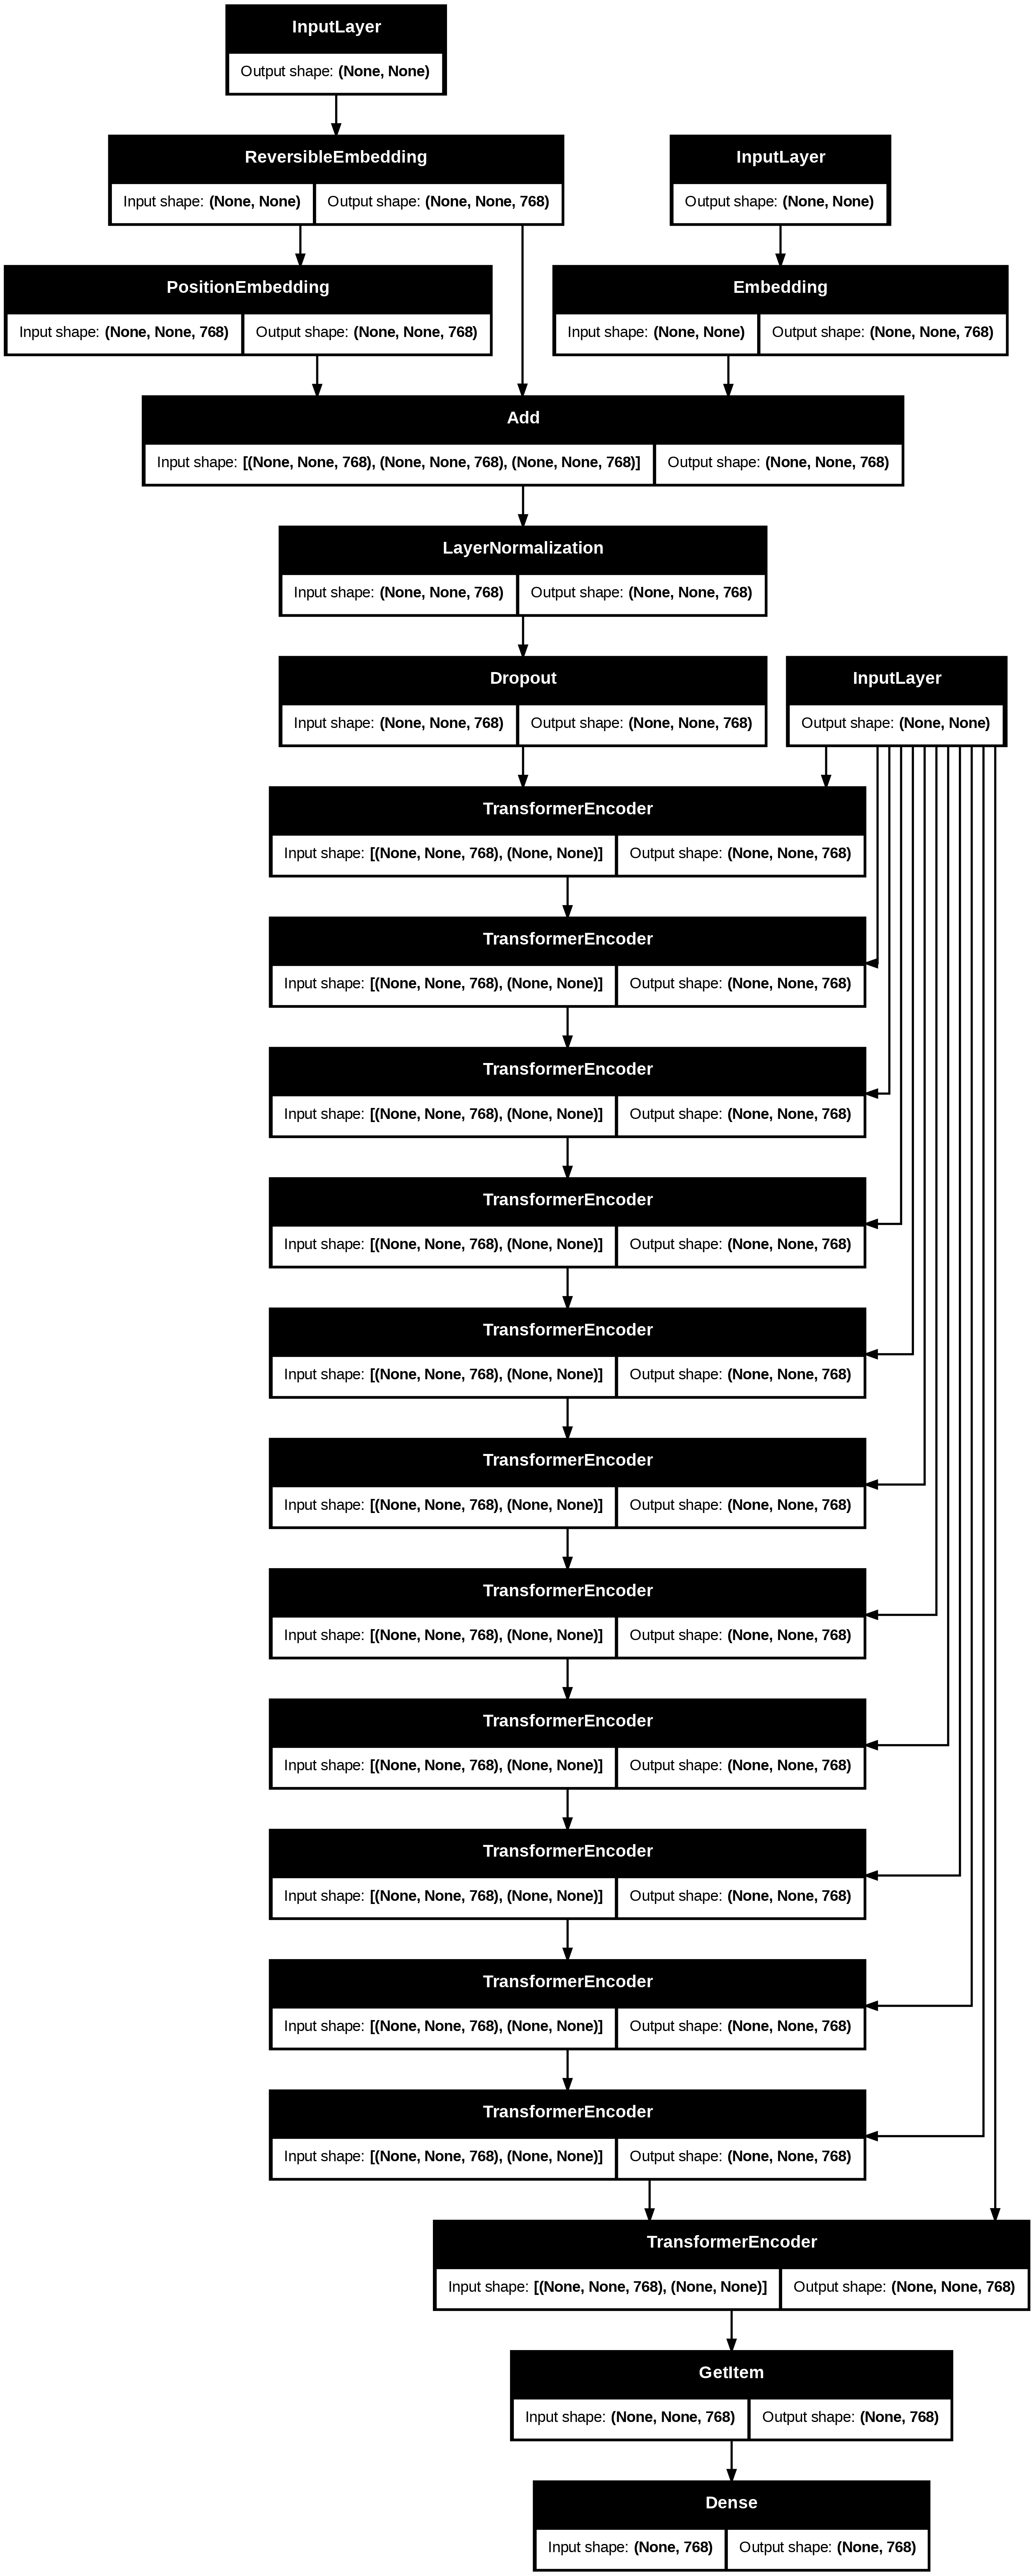

In [ ]:
# Visualize the structure
plot_model(image_backbone, show_shapes=True, expand_nested=True)
plot_model(text_backbone, show_shapes=True, expand_nested=True)

In [ ]:
class CLIPModel(keras.Model):
    def __init__(self, img_backbone, text_backbone, embed_dim=256, init_temp=0.1):
        super().__init__()
        self.img_backbone = img_backbone
        self.text_backbone = text_backbone

        self.img_proj = keras.layers.Dense(embed_dim, use_bias=False)
        self.text_proj = keras.layers.Dense(embed_dim, use_bias=False)

        self.logit_scale = tf.Variable(
            tf.math.log(1.0 / init_temp),
            trainable=True,
            dtype=tf.float32,
            name="logit_scale",
        )

        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def encode_image(self, images, training=False):
        backbone_training = training and self.img_backbone.trainable
        x = self.img_backbone(images, training=backbone_training)

        # KerasHub ResNet backbone may return a spatial feature map
        if isinstance(x, dict):
            # take the deepest pyramid level if needed
            if "P5" in x:
                x = x["P5"]
            else:
                x = list(x.values())[-1]

        if len(x.shape) == 4:
            x = tf.reduce_mean(x, axis=[1, 2])  # global average pooling

        x = self.img_proj(x)
        x = tf.math.l2_normalize(x, axis=-1)
        return x

    def encode_text(self, token_dict, training=False):
        backbone_training = training and self.text_backbone.trainable
        out = self.text_backbone(token_dict, training=backbone_training)

        if isinstance(out, dict):
            if "pooled_output" in out:
                x = out["pooled_output"]
            elif "sequence_output" in out:
                x = out["sequence_output"][:, 0, :]
            else:
                raise ValueError(f"Unexpected BERT output keys: {list(out.keys())}")
        else:
            if len(out.shape) == 3:
                x = out[:, 0, :]
            else:
                x = out

        x = self.text_proj(x)
        x = tf.math.l2_normalize(x, axis=-1)
        return x

    def compute_clip_loss(self, img_emb, txt_emb):
        img_emb = tf.cast(img_emb, tf.float32)
        txt_emb = tf.cast(txt_emb, tf.float32)

        # safer temperature handling
        logit_scale = tf.exp(tf.clip_by_value(self.logit_scale, 0.0, tf.math.log(100.0)))

        logits = tf.matmul(img_emb, txt_emb, transpose_b=True) * logit_scale
        logits = tf.clip_by_value(logits, -100.0, 100.0)

        labels = tf.range(tf.shape(logits)[0])

        loss_i2t = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=logits
        )
        loss_t2i = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=tf.transpose(logits)
        )

        loss = 0.5 * (loss_i2t + loss_t2i)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        images, token_dict = data

        with tf.GradientTape() as tape:
            img_emb = self.encode_image(images, training=True)
            txt_emb = self.encode_text(token_dict, training=True)
            loss = self.compute_clip_loss(img_emb, txt_emb)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        return {
            "loss": self.loss_tracker.result(),
            "temperature": tf.exp(-self.logit_scale),
        }

    def test_step(self, data):
        images, token_dict = data
        img_emb = self.encode_image(images, training=False)
        txt_emb = self.encode_text(token_dict, training=False)
        loss = self.compute_clip_loss(img_emb, txt_emb)

        self.loss_tracker.update_state(loss)
        return {
            "loss": self.loss_tracker.result(),
            "temperature": tf.exp(-self.logit_scale),
        }

In [ ]:
model = CLIPModel(image_backbone, text_backbone, embed_dim=EMBED_DIM)

optimizer = keras.optimizers.Adam(
    learning_rate=1e-4,
    global_clipnorm=1.0,
)
model.compile(optimizer=optimizer)

model.summary()

Model: "clip_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ res_net_backbone                │ (None, None, None,     │    23,561,152 │
│ (ResNetBackbone)                │ 2048)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bert_backbone (BertBackbone)    │ ((None, 768), (None,   │   109,482,240 │
│                                 │ None, 768))            │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,043,392 (507.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 133,043,392 (507.52 MB)

In [ ]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = keras.applications.resnet.preprocess_input(img)
    return img

In [ ]:
def preprocess_example(img_path, text):
    image = load_image(img_path)
    token_dict = text_preprocessor(text)
    return image, token_dict

In [ ]:
ds = tf.data.Dataset.from_tensor_slices((records, labels))
ds = ds.shuffle(len(records), seed=SEED)
ds = ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
ds = ds.batch(BATCH_SIZE)
ds = ds.prefetch(AUTOTUNE)

In [ ]:
train_records, val_records, train_labels, val_labels = train_test_split(
    records,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((train_records, train_labels))
train_ds = train_ds.shuffle(len(train_records), seed=SEED)
train_ds = train_ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_records, val_labels))
val_ds = val_ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
batch = next(iter(train_ds))
images, token_dict = batch

print("Images:", images.shape, images.dtype)
print("Token keys:", token_dict.keys())
for k, v in token_dict.items():
    print(k, v.shape, v.dtype)

Images: (4, 224, 224, 3) <dtype: 'float32'>
Token keys: dict_keys(['token_ids', 'padding_mask', 'segment_ids'])
token_ids (4, 32) <dtype: 'int32'>
padding_mask (4, 32) <dtype: 'bool'>
segment_ids (4, 32) <dtype: 'int32'>


In [ ]:
img_emb = model.encode_image(images[:2], training=False)
txt_emb = model.encode_text({k: v[:2] for k, v in token_dict.items()}, training=False)

print("Image embeddings:", img_emb.shape)
print("Text embeddings:", txt_emb.shape)

Image embeddings: (2, 256)
Text embeddings: (2, 256)


In [ ]:
out = model.train_step(batch)
print(out)

{'loss': <tf.Tensor: shape=(), dtype=float32, numpy=1.3863098621368408>, 'temperature': <tf.Tensor: shape=(), dtype=float32, numpy=0.10000000149011612>}


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
    ),
]

In [ ]:
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
)

Epoch 1/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 168s 33ms/step - loss: 1.1133 - temperature: 0.1000 - val_loss: 1.0536 - val_temperature: 0.1000 - learning_rate: 1.0000e-04
Epoch 2/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 167s 33ms/step - loss: 1.0935 - temperature: 0.1000 - val_loss: 1.0677 - val_temperature: 0.1000 - learning_rate: 1.0000e-04
Epoch 3/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 168s 33ms/step - loss: 1.0750 - temperature: 0.1000 - val_loss: 1.0663 - val_temperature: 0.1000 - learning_rate: 1.0000e-04
Epoch 4/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 168s 34ms/step - loss: 1.0326 - temperature: 0.1000 - val_loss: 1.0131 - val_temperature: 0.1000 - learning_rate: 5.0000e-05
Epoch 5/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 167s 33ms/step - loss: 1.0220 - temperature: 0.1000 - val_loss: 1.0409 - val_temperature: 0.1000 - learning_rate: 5.0000e-05


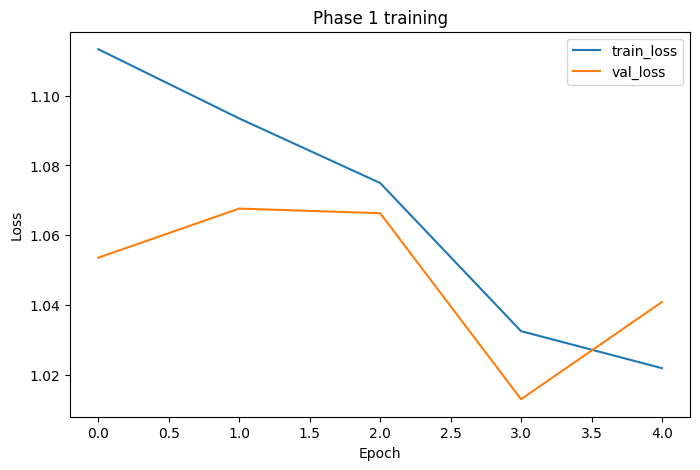

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_1.history["loss"], label="train_loss")
plt.plot(history_1.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Phase 1 training")
plt.show()

In [ ]:
class_token_dict = text_preprocessor(tf.constant(class_descriptions))
class_text_emb = model.encode_text(class_token_dict, training=False)
print(class_text_emb.shape)

(5, 256)


In [ ]:
label_map = {
    "colon_aca": "A histopathology image of colon adenocarcinoma",
    "colon_n": "A histopathology image of normal colon tissue",
    "lung_aca": "A histopathology image of lung adenocarcinoma",
    "lung_n": "A histopathology image of normal lung tissue",
    "lung_scc": "A histopathology image of lung squamous cell carcinoma",
}

class_names = list(label_map.keys())

In [ ]:
idx = np.random.randint(len(records))

img_path = records[idx]
true_label = labels[idx]

image = load_image(img_path)
image_batch = tf.expand_dims(image, axis=0)

img_emb = model.encode_image(image_batch, training=False)
scores = tf.matmul(img_emb, class_text_emb, transpose_b=True).numpy()[0]

pred_idx = np.argmax(scores)
pred_label = class_names[pred_idx]

print("Image path:", img_path)
print("True label:", true_label)
print("Predicted label:", label_map.get(pred_label))
print()

print("Scores:")
for cname, score in zip(class_names, scores):
    print(f"{cname:10s} -> {score:.4f}")

Image path: /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_aca/lungaca130.jpeg
True label: A histopathology image of lung adenocarcinoma
Predicted label: A histopathology image of colon adenocarcinoma

Scores:
colon_aca  -> 0.4726
colon_n    -> 0.2644
lung_aca   -> -0.0202
lung_n     -> 0.3113
lung_scc   -> 0.1021


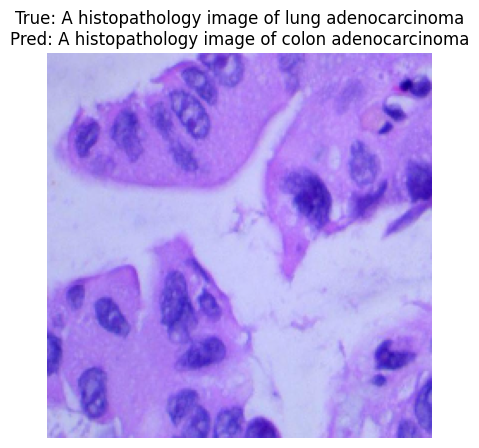

In [ ]:
plt.figure(figsize=(5,5))
img_show = image.numpy()

# undo ResNet preprocessing approximately for display
img_show = img_show[..., ::-1]   # BGR -> RGB
img_show = img_show - img_show.min()
img_show = img_show / (img_show.max() + 1e-8)

plt.imshow(img_show)
plt.title(f"True: {true_label}\nPred: {label_map.get(pred_label)}")
plt.axis("off")
plt.show()

In [ ]:
class_prompts = sorted(list(set(val_labels)))
print(class_prompts)

prompt_to_id = {p: i for i, p in enumerate(class_prompts)}
id_to_prompt = {i: p for p, i in prompt_to_id.items()}

keys = tf.constant(class_prompts)
values = tf.constant(np.arange(len(class_prompts)), dtype=tf.int32)

table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values),
    default_value=-1
)

# Encode prompts once
class_token_dict = text_preprocessor(tf.constant(class_prompts))
class_text_emb = model.encode_text(class_token_dict, training=False)

['A histopathology image of colon adenocarcinoma', 'A histopathology image of colon benign tissue', 'A histopathology image of lung adenocarcinoma', 'A histopathology image of lung benign tissue', 'A histopathology image of lung squamous cell carcinoma']


In [ ]:
def preprocess_eval_example(img_path, label):
    image = load_image(img_path)
    class_id = table.lookup(label)
    return image, class_id

val_eval_ds = tf.data.Dataset.from_tensor_slices((val_records, val_labels))
val_eval_ds = val_eval_ds.map(preprocess_eval_example, num_parallel_calls=AUTOTUNE)
val_eval_ds = val_eval_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
all_preds = []
all_true = []
all_images = []

for images, true_ids in val_eval_ds:
    img_emb = model.encode_image(images, training=False)
    scores = tf.matmul(img_emb, class_text_emb, transpose_b=True)
    pred_ids = tf.argmax(scores, axis=1, output_type=tf.int32)

    all_preds.extend(pred_ids.numpy().tolist())
    all_true.extend(true_ids.numpy().tolist())
    all_images.extend(images.numpy())

all_preds = np.array(all_preds, dtype=np.int32)
all_true = np.array(all_true, dtype=np.int32)
all_images = np.array(all_images)

print("Unique true:", np.unique(all_true))
print("Unique pred:", np.unique(all_preds))

acc = (all_preds == all_true).mean()
print("Validation accuracy:", acc)

Unique true: [0 1 2 3 4]
Unique pred: [0 1 2 3 4]
Validation accuracy: 0.5836


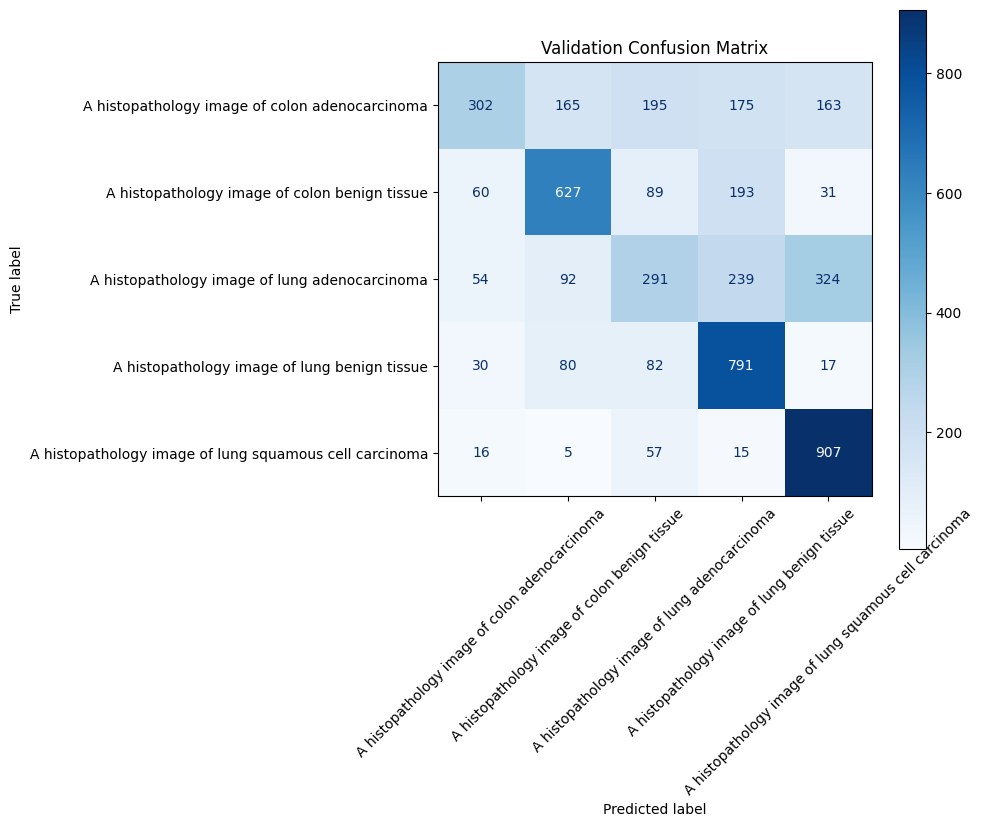

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_true, all_preds, labels=list(range(len(class_prompts))))

fig, ax = plt.subplots(figsize=(7,7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_prompts)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Validation Confusion Matrix")
plt.show()

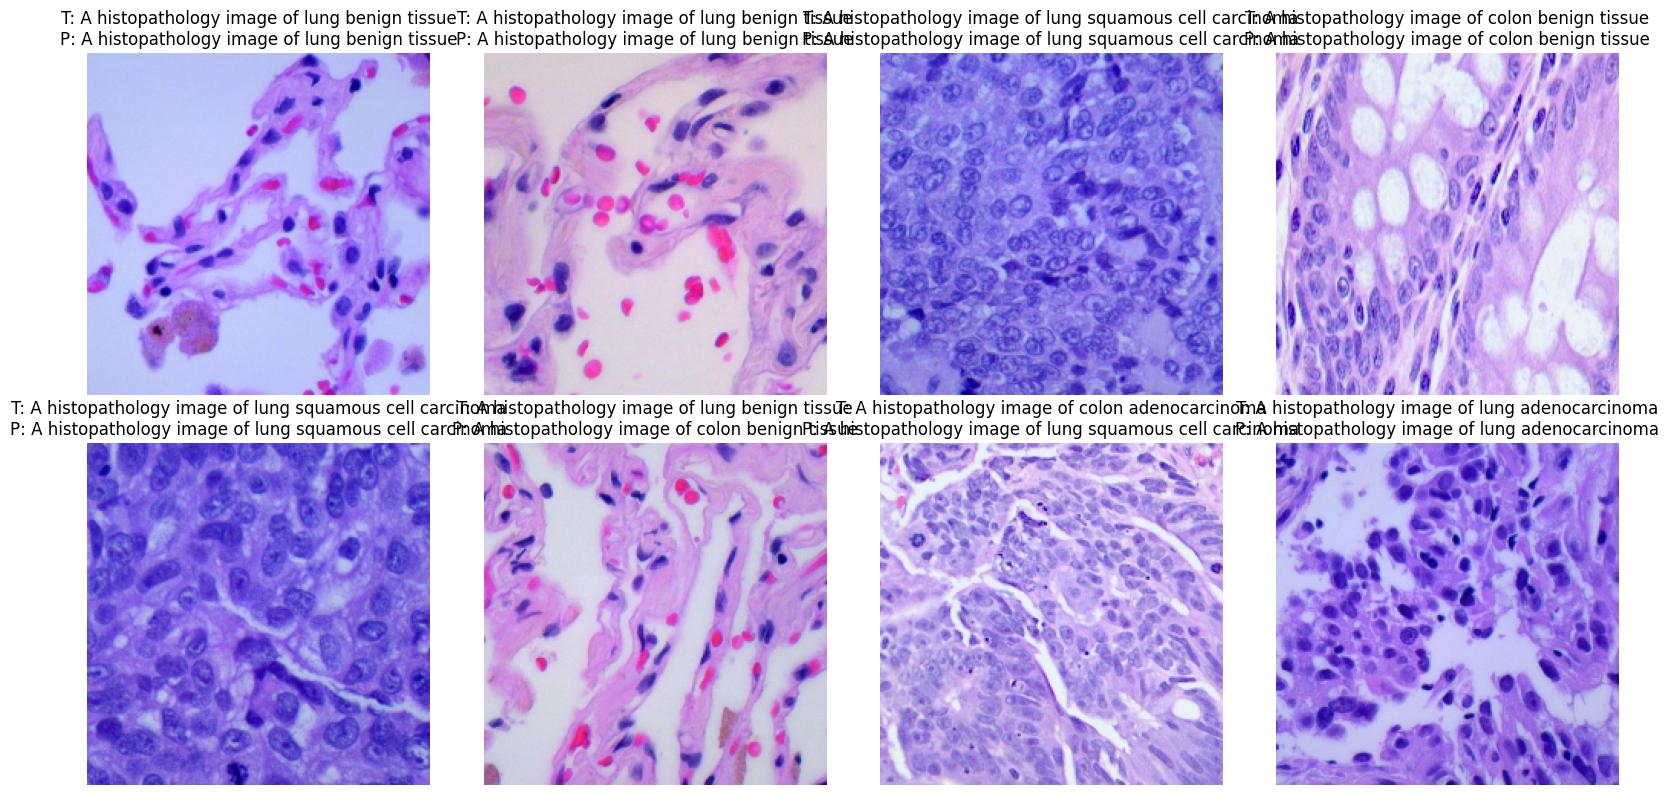

In [ ]:
n_show = 8
idxs = np.random.choice(len(all_true), size=n_show, replace=False)

plt.figure(figsize=(16, 8))
for i, idx in enumerate(idxs):
    plt.subplot(2, 4, i + 1)

    img = all_images[idx]
    img = img[..., ::-1]
    img = img - img.min()
    img = img / (img.max() + 1e-8)

    true_label = id_to_prompt[int(all_true[idx])]
    pred_label = id_to_prompt[int(all_preds[idx])]

    plt.imshow(img)
    plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
all_emb = []

for images, _ in val_eval_ds:
    emb = model.encode_image(images, training=False)
    all_emb.append(emb.numpy())

all_emb = np.concatenate(all_emb, axis=0)

print("Embedding shape:", all_emb.shape)

Embedding shape: (5000, 256)


In [ ]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

emb_2d = reducer.fit_transform(all_emb)

print(emb_2d.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(5000, 2)


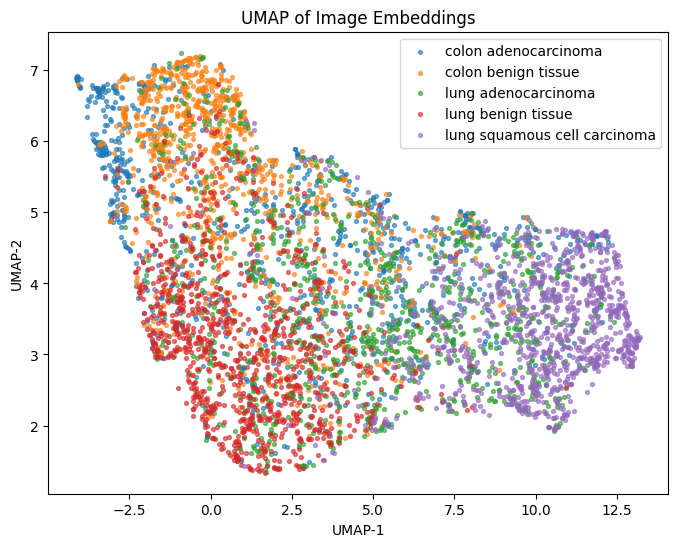

In [ ]:
plt.figure(figsize=(8,6))

for i, prompt in id_to_prompt.items():
    idx = all_true == i
    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        s=8,
        alpha=0.6,
        label=prompt.replace("A histopathology image of ","")
    )

plt.legend()
plt.title("UMAP of Image Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()